Dataset Info:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape: (200, 5)

Missing values: CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000      

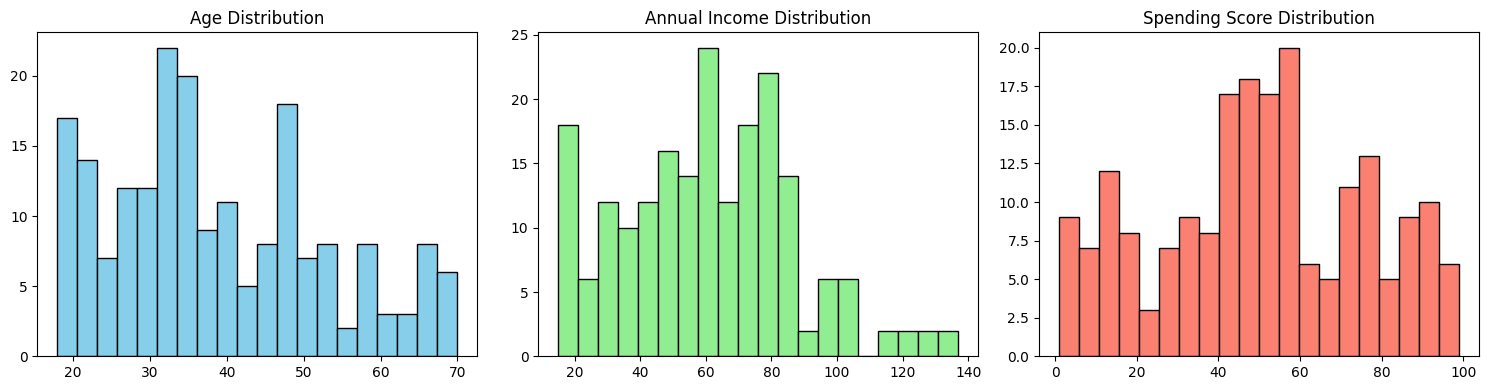

In [ ]:
#K-Means Clustering

#Load & Eksplorasi Data

#Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

#Load Dataset
#Dataset: Age, Annual Income (k$), Spending Score (1-100)
# Alternative: create synthetic customer data
# np.random.seed(42)
# n_customers = 200
# age = np.random.normal(40, 12, n_customers).clip(18, 70)
# income = np.random.normal(60, 25, n_customers).clip(15, 140)
# spending_score = np.random.normal(50, 25, n_customers).clip(1, 100)

# df = pd.DataFrame({
#     'CustomerID': range(1, n_customers + 1),
#     'Age': age,
#     'Annual_Income_k$': income,
#     'Spending_Score': spending_score
# })

df = pd.read_csv("Mall_Customers.csv")

print("Dataset Info:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nMissing values: {df.isnull().sum()}")
print("\nStatistical Summary:")
print(df.describe())

#Visualisasi Distribusi Fitur
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['Age'], bins = 20, color='skyblue', edgecolor='black') #bins = jumlah bar dalam histogram/data dibagi ke berapa kelompok, edgecolor = warna garis tepi
axes[0].set_title('Age Distribution')
axes[1].hist(df['Annual Income (k$)'], bins = 20, color='lightgreen', edgecolor='black')
axes[1].set_title('Annual Income Distribution')
axes[2].hist(df['Spending Score (1-100)'], bins = 20, color='salmon', edgecolor='black')
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

Before Scaling:
Mean: [60.56 50.2 ]
Std: [26.19897708 25.75888196]

After scaling:
Mean: [-2.13162821e-16 -1.46549439e-16]
Std: [1. 1.]


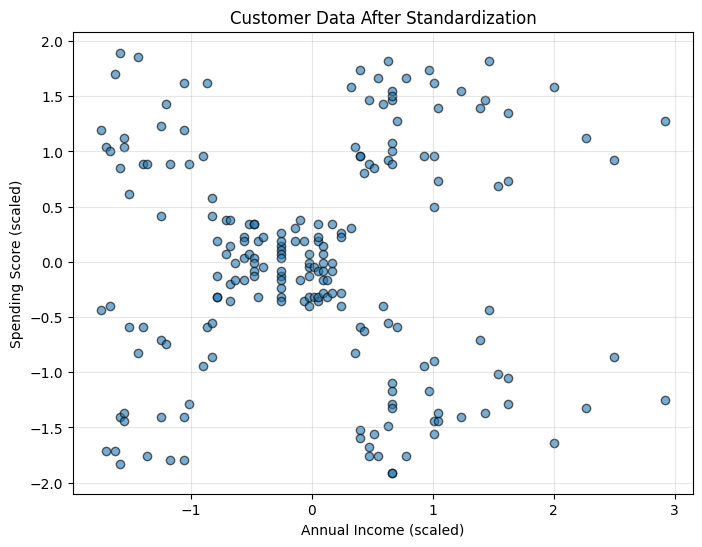

In [12]:
#Pilih Fitur untuk Clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

#Scaling Data (Wajib untuk K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before Scaling:")
print(f"Mean: {X.mean(axis=0)}")
print(f"Std: {X.std(axis=0)}")
print("\nAfter scaling:")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}") #Menantukan axis bisa dari melihat shape

#Visualiasikan Data Setelah Scaling
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[: , 1], alpha=0.6, edgecolors='k')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Customer Data After Standardization')
plt.grid(alpha=0.3)
plt.show()

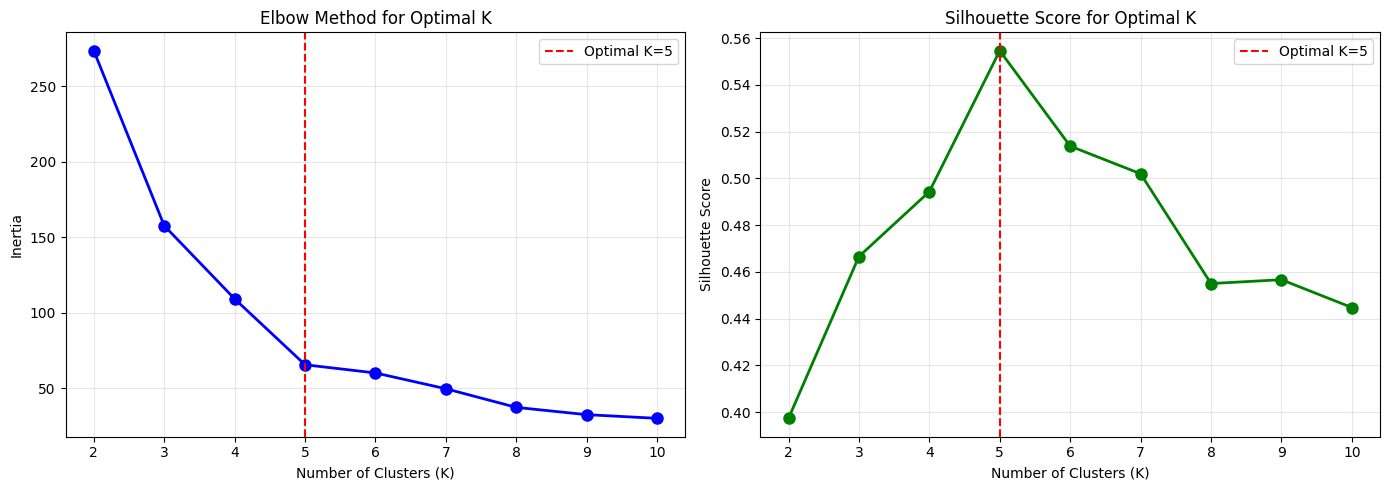

Recommended K from Elbow: 5
Best Silhouette Score at K-5: 0.555


In [13]:
#Elbow Method & Silhouette Score untuk Menentukan Jumlah Cluster Optimal
#Elbow Method (Inertia)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

#Plot Elbow Method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal K')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Recommended K from Elbow: 5")
print(f"Best Silhouette Score at K-5: {silhouette_scores[3]:.3f}")


K-Means Clustering Results:

 Cluster Centers (in original scaled):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Cluster Sizes:
Cluster KMeans
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Summary:


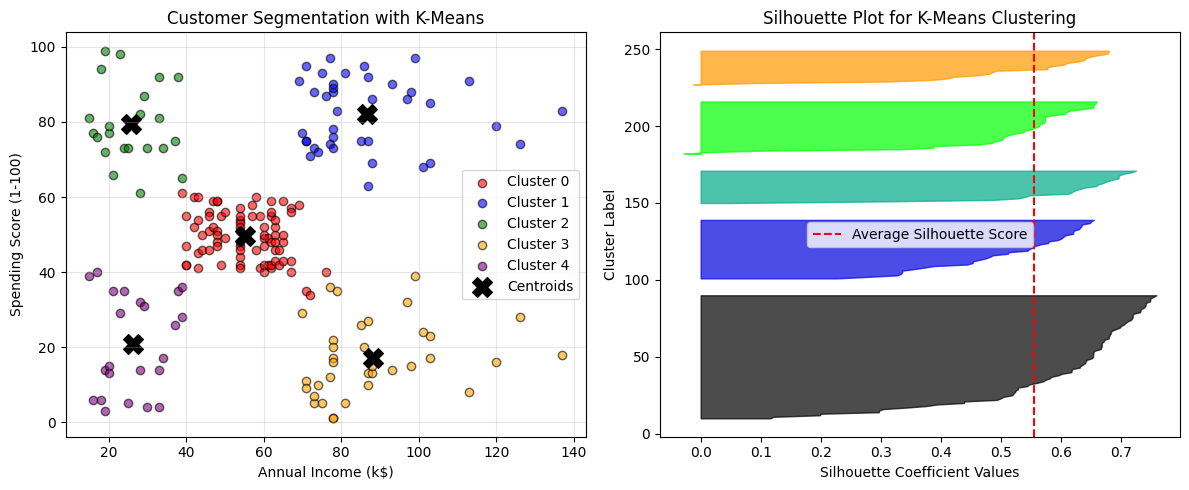


Interpretation of Clusters:
Cluster 0: Medium Income - Medium Spenders (Kelas Menengah) - Pelanggan yang memiliki pendapatan dan kebiasaan belanja rata-rata | Size: 81 customers (40.5%)
Cluster 1: High Income - High Spenders (Premium/VVIP) - Pelanggan dengan pendapatan tinggi dan kebiasaan belanja yang tinggi | Size: 39 customers (19.5%)
Cluster 2: Low Income - High Spenders (Borongan/Budak Promo) - Pelanggan dengan pendapatan rendah tetapi kebiasaan belanja yang tinggi | Size: 22 customers (11.0%)
Cluster 3: High Income - Low Spenders (Hemat) - Mungkin pelanggan yang lebih tua atau lebih muda dengan pendapatan tinggi tetapi tidak terlalu sering berbelanja | Size: 35 customers (17.5%)
Cluster 4: Low Income - Low Spenders (Terbatas) - Pelanggan dengan pendapatan rendah dan kebiasaan belanja yang terbatas | Size: 23 customers (11.5%)


In [16]:
#Implementasi K-Means dengan K Optimal
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster KMeans'] = kmeans.fit_predict(X_scaled)

#Analisis hasil clustering
print("K-Means Clustering Results:")
print("\n Cluster Centers (in original scaled):")
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df.index.name = 'Cluster'
print(centers_df)

print("\nCluster Sizes:")
print(df['Cluster KMeans'].value_counts().sort_index())

#Analisis Karakteristik Setiap Cluster
cluster_summary = df.groupby('Cluster KMeans')[features].agg(['mean', 'std', 'count'])
print("\nCluster Summary:")

#Visualisasi Cluster
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green', 'orange', 'purple']
for cluster in range(5):
    cluster_data = df[df['Cluster KMeans'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[cluster], label=f"Cluster {cluster}",
                alpha=0.6, edgecolors='k')
plt.scatter(centers_original[:,0], centers_original[:,1],
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation with K-Means')
plt.legend()
plt.grid(alpha=0.3)

#Silhouette Plot
plt.subplot(1, 2, 2)
silhouette_vals = silhouette_samples(X_scaled, df['Cluster KMeans'])
y_lower = 10
for i in range(5):
    cluster_silhouette = silhouette_vals[df['Cluster KMeans'] == i]
    cluster_silhouette.sort()
    size_cluster = len(cluster_silhouette)
    y_upper = y_lower + size_cluster
    color = plt.cm.nipy_spectral(float(i) / 5)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette,
                      facecolor = color, edgecolor=color, alpha=0.7)
    y_lower = y_upper + 10

plt.axvline(x=silhouette_score(X_scaled, df['Cluster KMeans']),
            color='red', linestyle='--', label='Average Silhouette Score')
plt.xlabel('Silhouette Coefficient Values')
plt.ylabel('Cluster Label')
plt.title('Silhouette Plot for K-Means Clustering')
plt.legend()
plt.tight_layout()
plt.show()

#Interpretasi segmentasi
print("\nInterpretation of Clusters:")
interpretation = {
    0: "Medium Income - Medium Spenders (Kelas Menengah) - Pelanggan yang memiliki pendapatan dan kebiasaan belanja rata-rata",
    1: "High Income - High Spenders (Premium/VVIP) - Pelanggan dengan pendapatan tinggi dan kebiasaan belanja yang tinggi",
    2: "Low Income - High Spenders (Borongan/Budak Promo) - Pelanggan dengan pendapatan rendah tetapi kebiasaan belanja yang tinggi",
    3: "High Income - Low Spenders (Hemat) - Mungkin pelanggan yang lebih tua atau lebih muda dengan pendapatan tinggi tetapi tidak terlalu sering berbelanja",
    4: "Low Income - Low Spenders (Terbatas) - Pelanggan dengan pendapatan rendah dan kebiasaan belanja yang terbatas",
}

for cluster, label in interpretation.items():
    size = df[df['Cluster KMeans'] == cluster].shape[0]
    print(f"Cluster {cluster}: {label} | Size: {size} customers ({size/len(df)*100:.1f}%)")